In [2]:
import zipfile

zip_path = "/content/archive (5).zip"
extract_path = "/content/archive (5)"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done!")

Extraction Done!


In [3]:
import os
for root, dirs, files in os.walk("/content/archive (5)/DATASET"):
    print(f"{root} → {len(files)} files")

/content/archive (5)/DATASET → 0 files
/content/archive (5)/DATASET/classification → 0 files
/content/archive (5)/DATASET/classification/Training → 0 files
/content/archive (5)/DATASET/classification/Training/meningioma → 1339 files
/content/archive (5)/DATASET/classification/Training/notumor → 1595 files
/content/archive (5)/DATASET/classification/Training/glioma → 1321 files
/content/archive (5)/DATASET/classification/Training/pituitary → 1457 files
/content/archive (5)/DATASET/classification/Testing → 0 files
/content/archive (5)/DATASET/classification/Testing/meningioma → 306 files
/content/archive (5)/DATASET/classification/Testing/notumor → 405 files
/content/archive (5)/DATASET/classification/Testing/glioma → 300 files
/content/archive (5)/DATASET/classification/Testing/pituitary → 300 files
/content/archive (5)/DATASET/Segmentation → 0 files
/content/archive (5)/DATASET/Segmentation/Pituitary tumor → 1860 files
/content/archive (5)/DATASET/Segmentation/Meningioma → 1416 files
/

# UNET

In [4]:
import os

main_path  = "/content/archive (5)/DATASET/Segmentation/"

seg_classes = ['Glioma','Meningioma','Pituitary tumor']
SEG_IMG_SIZE = 256

In [33]:
def add_mask(x):
    nsplit = x.split('.')
    fname = nsplit[0] + '_mask.' + nsplit[1]
    return fname

dict_aux = {'filepath':[],'label':[],'encoded_label':[]}
for c in seg_classes:
    class_path = os.path.join(main_path,c)
    encoded_label = seg_classes.index(c) #Match the id from the classification model above
    for fn in os.listdir(class_path):
        dict_aux['filepath'].append( os.path.join(class_path,fn) )
        dict_aux['label'].append(c)
        dict_aux['encoded_label'].append(encoded_label)

seg_df = pd.DataFrame(dict_aux)
seg_df = seg_df.loc[ ~seg_df.filepath.str.contains('_mask')].copy()
seg_df.reset_index(inplace=True)
seg_df['maskpath'] = seg_df.filepath.apply(add_mask)
seg_df = seg_df.sample(frac=1)

In [34]:
train_seg, test_seg = train_test_split(seg_df,test_size=0.15,random_state=99)

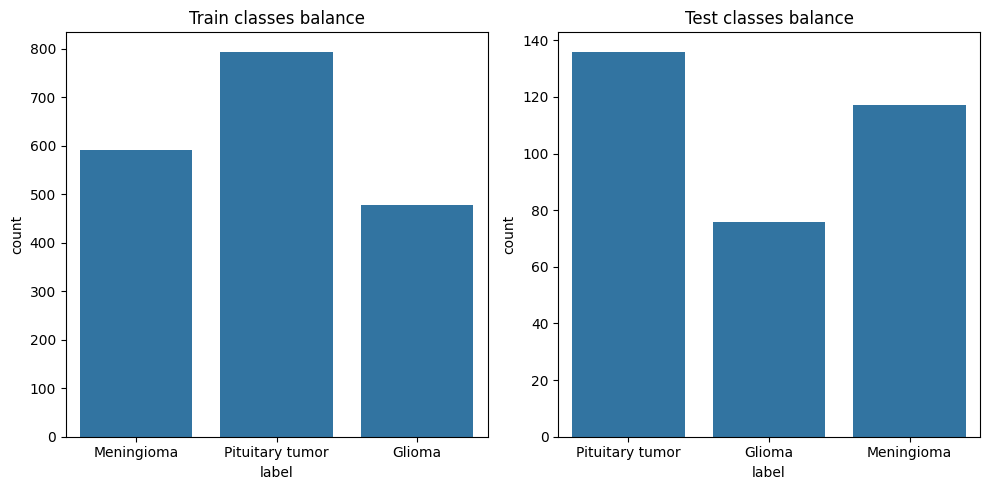

In [35]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.countplot(x = train_seg.label)
plt.title('Train classes balance')

plt.subplot(1,2,2)
sns.countplot(x = test_seg.label)
plt.title('Test classes balance')

plt.tight_layout()
plt.show()


In [36]:
len(test_seg),len(train_seg)

(329, 1863)

In [37]:
train_paths_input = train_seg.filepath.tolist()
train_paths_output = train_seg.maskpath.tolist()
train_classes_seg = train_seg.encoded_label.tolist()

test_paths_input = test_seg.filepath.tolist()
test_paths_output = test_seg.maskpath.tolist()
test_classes_seg = test_seg.encoded_label.tolist()

In [38]:
def load_and_preprocess_image_seg(input_path_, output_path_, training=True):
    input_image = tf.io.read_file(input_path_)
    output_image = tf.io.read_file(output_path_)

    input_image = tf.image.decode_png(input_image,channels=1)
    output_image = tf.image.decode_png(output_image,channels=1)

    input_image = tf.cast(input_image, tf.float32) / 255.0
    output_image = tf.cast(output_image, tf.float32) / 255.0

    if training:
       input_image,output_image = augment_image_seg(input_image,output_image)

    input_image = tf.image.resize(input_image, [SEG_IMG_SIZE, SEG_IMG_SIZE])
    output_image = tf.image.resize(output_image, [SEG_IMG_SIZE, SEG_IMG_SIZE])
        #Binarize mask after resizing
    output_image = tf.cast(output_image > 0.15, tf.float32)

    return input_image,output_image

def augment_image_seg(input_image,output_image):
    if tf.random.uniform([]) > 0.5:
        input_image = tf.image.flip_left_right(input_image)
        output_image = tf.image.flip_left_right(output_image)
    if tf.random.uniform([]) > 0.5:
        input_image = tf.image.flip_up_down(input_image)
        output_image = tf.image.flip_up_down(output_image)
    if tf.random.uniform([]) > 0.5:
        k_rot = tf.random.uniform([],minval=1,maxval=4,dtype=tf.int32)
        input_image = tf.image.rot90(input_image,k=k_rot)
        output_image = tf.image.rot90(output_image,k=k_rot)
    return input_image,output_image


In [39]:
BATCH_SIZE = 16#32

train_ds_seg = tf.data.Dataset.from_tensor_slices((train_paths_input, train_paths_output))
train_ds_seg = train_ds_seg.map(
    lambda x, y: load_and_preprocess_image_seg(x, y, training=True),
    num_parallel_calls=tf.data.AUTOTUNE
)
train_ds_seg = train_ds_seg.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds_seg = tf.data.Dataset.from_tensor_slices((test_paths_input, test_paths_output))
test_ds_seg = test_ds_seg.map(
    lambda x, y: load_and_preprocess_image_seg(x, y, training=False),
    num_parallel_calls=tf.data.AUTOTUNE
)
test_ds_seg = test_ds_seg.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [40]:
inputs = Input((SEG_IMG_SIZE,SEG_IMG_SIZE,1))

# Encoder (Downsampling)
c1 = Conv2D(32, 3, activation='relu', padding='same')(inputs)
c1 = Conv2D(32, 3, activation='relu', padding='same')(c1)
p1 = MaxPool2D()(c1)

c2 = Conv2D(64, 3, activation='relu', padding='same')(p1)
c2 = Conv2D(64, 3, activation='relu', padding='same')(c2)
p2 = MaxPool2D()(c2)

c3 = Conv2D(128, 3, activation='relu', padding='same')(p2)
c3 = Conv2D(128, 3, activation='relu', padding='same')(c3)
p3 = MaxPool2D()(c3)

c4 = Conv2D(256, 3, activation='relu', padding='same')(p3)
c4 = Conv2D(256, 3, activation='relu', padding='same')(c4)
p4 = MaxPool2D()(c4)

# Bottleneck
c5 = Conv2D(512, 3, activation='relu', padding='same')(p4)
c5 = Conv2D(512, 3, activation='relu', padding='same')(c5)

# Decoder (Upsampling)
u6 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c5)
u6 = concatenate([u6, c4])
c6 = Conv2D(256, 3, activation='relu', padding='same')(u6)
c6 = Conv2D(256, 3, activation='relu', padding='same')(c6)

u7 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c6)
u7 = concatenate([u7, c3])
c7 = Conv2D(128, 3, activation='relu', padding='same')(u7)
c7 = Conv2D(128, 3, activation='relu', padding='same')(c7)

u8 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c7)
u8 = concatenate([u8, c2])
c8 = Conv2D(64, 3, activation='relu', padding='same')(u8)
c8 = Conv2D(64, 3, activation='relu', padding='same')(c8)


u9 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c8)
u9 = concatenate([u9, c1], axis=3)
c9 = Conv2D(32, 3, activation='relu', padding='same')(u9)
c9 = Conv2D(32, 3, activation='relu', padding='same')(c9)

outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)

model_seg = Model(inputs=[inputs], outputs=[outputs])
model_seg.compile(optimizer = Adam(learning_rate=0.001), loss = 'binary_crossentropy', metrics = ['accuracy'])


In [41]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/unet_best.keras",  # ✅ changed from .h5
        save_best_only=True
    )
]

In [42]:
model_seg.fit(train_ds_seg,validation_data=test_ds_seg, epochs = 45, callbacks=callbacks)

Epoch 1/45
117/117 ━━━━━━━━━━━━━━━━━━━━ 131s 682ms/step - accuracy: 0.9746 - loss: 0.1358 - val_accuracy: 0.9819 - val_loss: 0.0759
Epoch 2/45
117/117 ━━━━━━━━━━━━━━━━━━━━ 43s 312ms/step - accuracy: 0.9831 - loss: 0.0707 - val_accuracy: 0.9819 - val_loss: 0.0723
Epoch 3/45
117/117 ━━━━━━━━━━━━━━━━━━━━ 41s 307ms/step - accuracy: 0.9831 - loss: 0.0663 - val_accuracy: 0.9819 - val_loss: 0.0700
Epoch 4/45
117/117 ━━━━━━━━━━━━━━━━━━━━ 41s 303ms/step - accuracy: 0.9831 - loss: 0.0618 - val_accuracy: 0.9819 - val_loss: 0.0724
Epoch 5/45
117/117 ━━━━━━━━━━━━━━━━━━━━ 43s 309ms/step - accuracy: 0.9831 - loss: 0.0620 - val_accuracy: 0.9819 - val_loss: 0.0685
Epoch 6/45
117/117 ━━━━━━━━━━━━━━━━━━━━ 41s 307ms/step - accuracy: 0.9831 - loss: 0.0571 - val_accuracy: 0.9819 - val_loss: 0.0578
Epoch 7/45
117/117 ━━━━━━━━━━━━━━━━━━━━ 42s 313ms/step - accuracy: 0.9831 - loss: 0.0534 - val_accuracy: 0.9819 - val_loss: 0.0562
Epoch 8/45
117/117 ━━━━━━━━━━━━━━━━━━━━ 43s 308ms/step - accuracy: 0.9834 - loss: 

In [43]:
y_pred = model_seg.predict(test_ds_seg)
y_pred = (y_pred > 0.5).astype(np.uint8)

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 196ms/step


In [44]:
y_true = []
for _, y_true_ in test_ds_seg:
    y_true.append(y_true_.numpy())
y_true = np.concatenate(y_true, axis=0)  # single NumPy array

In [45]:
f1_score(y_true.flatten(), y_pred.flatten())

0.6990293251826512

In [46]:
accuracy_score(y_true.flatten(), y_pred.flatten())

0.9904642771804949

In [47]:
confusion_matrix(y_true.flatten(), y_pred.flatten())

array([[21116976,    54884],
       [  150719,   238765]])

In [51]:
def visualize_results(n,source='test'):
    for _ in range(n):
        if source == 'test':
            img_input_paths = test_paths_input
            img_output_paths = test_paths_output
            type_labels = test_classes_seg
        else:
            img_input_paths = train_paths_input
            img_output_paths = train_paths_output
            type_labels = train_classes_seg

        img_pick = random.randint(0,len(img_input_paths)-1)

        img_input_path = img_input_paths[img_pick]
        img_output_path = img_output_paths[img_pick]
        type_label = type_labels[img_pick]

        img_inp,img_out = load_and_preprocess_image_seg(img_input_path, img_output_path, training=False)
        img_inp = tf.expand_dims(img_inp, axis=0)
        img_pred = model_seg.predict(img_inp)
        img_pred_bin = (img_pred[0] > 0.5).astype(np.uint8)


        plt.figure(figsize=(10,5))
        plt.subplot(1,3,1)
        plt.title(f'Original image {classes[type_label]}')
        plt.imshow(img_inp[0],cmap='gray')
        plt.grid(False)
        plt.axis('off')

        plt.subplot(1,3,2)
        plt.imshow(img_inp[0],cmap='gray')
        plt.imshow(img_out,cmap='Reds',alpha=img_out[:,:,0]/2)
        plt.grid(False)
        plt.axis('off')
        plt.title(f'Expected area detection')

        plt.subplot(1,3,3)
        plt.imshow(img_inp[0],cmap='gray')
        plt.imshow(img_pred_bin,cmap='Reds',alpha=img_pred_bin[:,:,0]/2)
        plt.grid(False)
        plt.axis('off')
        plt.title(f'Area detected')

        plt.tight_layout()
        plt.show()




1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


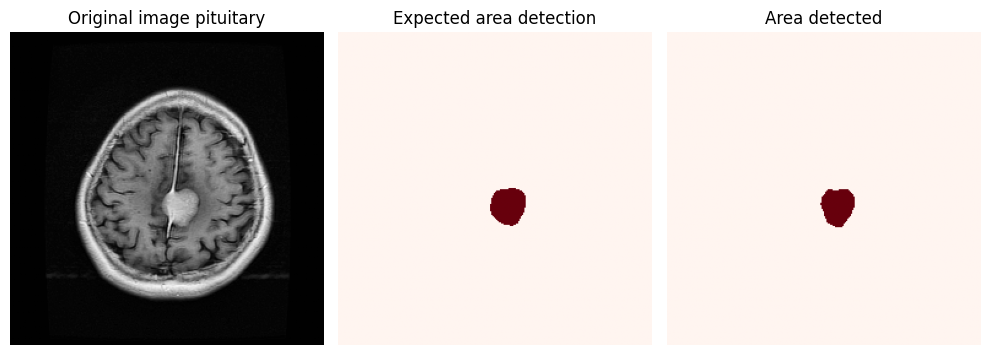

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


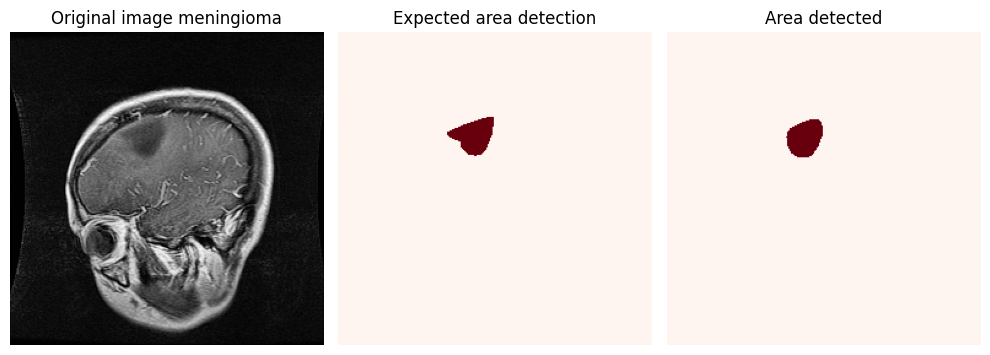

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


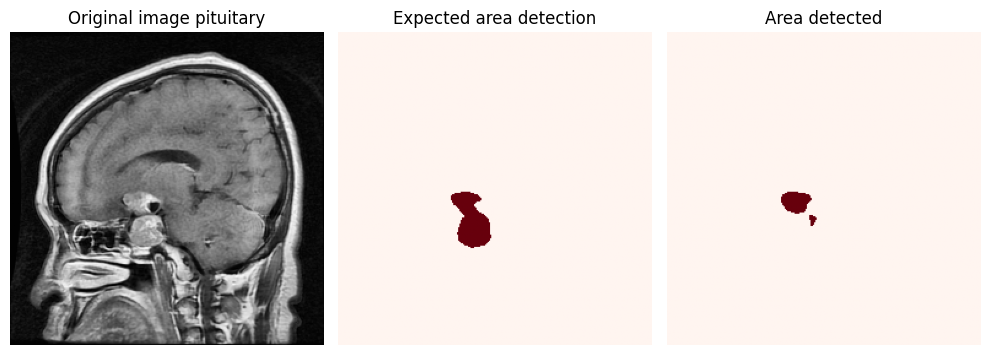

In [52]:
visualize_results(3)

✔ Skip connections → retain tumor boundaries

✔ Deep bottleneck → strong feature extraction

✔ Sigmoid → binary mask output

# CNN CLASSIFICATION

STEP 5.1: DEFINE PATHS

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image

from tensorflow.keras.layers import Conv2D,MaxPool2D,Flatten,Dense,UpSampling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential,load_model

#U-net only
from tensorflow.keras.layers import Input,Conv2DTranspose,concatenate
from tensorflow.keras.models import Model

import tensorflow as tf

import numpy as np
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score
from sklearn.model_selection import train_test_split
import random

In [9]:
train_dir = "/content/archive (5)/DATASET/classification/Training"
test_dir = "/content/archive (5)/DATASET/classification/Testing"
classes = ['glioma','meningioma','pituitary','notumor']
RED_IMG_SIZE = 128
ORIG_IMG_SIZE = 512
seed = 99
tf.random.set_seed(seed)
#random.seed(seed)
np.random.seed(seed)

In [10]:
def generate_dataframe(dir):
    dict_aux = { 'filedir':[],'label':[]}#,'width':[],'height':[] }
    for c in classes:
        class_dir = os.path.join(dir,c)
        for file_name in os.listdir(class_dir):
            filedir = os.path.join(class_dir,file_name)
            dict_aux['filedir'].append(  filedir )
            dict_aux['label'].append(c)

            # img = Image.open(filedir)
            # dict['width'] = img.width
            # dict['height'] = img.height

    df = pd.DataFrame(dict_aux)
    df = df.sample(frac=1)
    df.reset_index(inplace=True)
    return df

In [11]:
train_df = generate_dataframe(train_dir)
test_df = generate_dataframe(test_dir)

In [12]:
train_df.info(),test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5712 entries, 0 to 5711
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   index    5712 non-null   int64 
 1   filedir  5712 non-null   object
 2   label    5712 non-null   object
dtypes: int64(1), object(2)
memory usage: 134.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   index    1311 non-null   int64 
 1   filedir  1311 non-null   object
 2   label    1311 non-null   object
dtypes: int64(1), object(2)
memory usage: 30.9+ KB


(None, None)

In [13]:
train_df.sample(5)

,index,filedir,label
5469,1265,/content/archive (5)/DATASET/classification/Tr...,glioma
1715,5233,/content/archive (5)/DATASET/classification/Tr...,notumor
4721,5263,/content/archive (5)/DATASET/classification/Tr...,notumor
331,4929,/content/archive (5)/DATASET/classification/Tr...,notumor
1272,394,/content/archive (5)/DATASET/classification/Tr...,glioma


In [14]:
test_df.sample(5)

,index,filedir,label
1072,1075,/content/archive (5)/DATASET/classification/Te...,notumor
135,337,/content/archive (5)/DATASET/classification/Te...,meningioma
45,947,/content/archive (5)/DATASET/classification/Te...,notumor
1029,746,/content/archive (5)/DATASET/classification/Te...,pituitary
631,233,/content/archive (5)/DATASET/classification/Te...,glioma


In [15]:
train_df.isna().any().any(),test_df.isna().any().any()

(np.False_, np.False_)

In [16]:
train_df.filedir.duplicated().any(),test_df.filedir.duplicated().any()

(np.False_, np.False_)

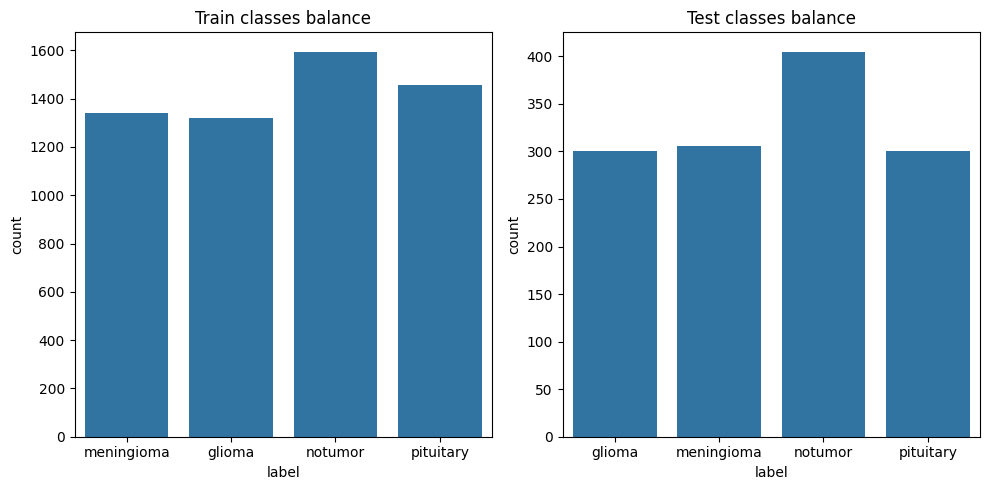

In [17]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sns.countplot(x = train_df.label)
plt.title('Train classes balance')

plt.subplot(1,2,2)
sns.countplot(x = test_df.label)
plt.title('Test classes balance')

plt.tight_layout()
plt.show()

In [18]:
train_df = pd.concat([train_df,pd.get_dummies(train_df.label).astype(int)[classes]],axis=1)
test_df = pd.concat([test_df,pd.get_dummies(test_df.label).astype(int)[classes]],axis=1)

In [19]:
train_df.sample(5)

,index,filedir,label,glioma,meningioma,pituitary,notumor
3345,1098,/content/archive (5)/DATASET/classification/Tr...,glioma,1,0,0,0
4085,2502,/content/archive (5)/DATASET/classification/Tr...,meningioma,0,1,0,0
4483,1150,/content/archive (5)/DATASET/classification/Tr...,glioma,1,0,0,0
3724,4697,/content/archive (5)/DATASET/classification/Tr...,notumor,0,0,0,1
4563,214,/content/archive (5)/DATASET/classification/Tr...,glioma,1,0,0,0


In [20]:
test_df.sample(5)

,index,filedir,label,glioma,meningioma,pituitary,notumor
1085,21,/content/archive (5)/DATASET/classification/Te...,glioma,1,0,0,0
439,1176,/content/archive (5)/DATASET/classification/Te...,notumor,0,0,0,1
64,953,/content/archive (5)/DATASET/classification/Te...,notumor,0,0,0,1
728,854,/content/archive (5)/DATASET/classification/Te...,pituitary,0,0,1,0
722,1001,/content/archive (5)/DATASET/classification/Te...,notumor,0,0,0,1


In [21]:
len(train_df),len(test_df)

(5712, 1311)

In [22]:
train_paths = train_df.filedir.tolist()
train_labels = train_df[classes].values

test_paths = test_df.filedir.tolist()
test_labels = test_df[classes].values

In [23]:
def load_and_preprocess_image(path, label, training=True):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=1)
    image = tf.cast(image, tf.float32) / 255.0
    if training:
        image = augment_image(image)
    image = tf.image.resize(image, [RED_IMG_SIZE, RED_IMG_SIZE])
    return image,label

def augment_image(image, ):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    if tf.random.uniform([]) > 0.5:
        image = tf.image.rot90(image,k=tf.random.uniform([],minval=1,maxval=4,dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)

    return image

In [24]:
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(
    lambda x, y: load_and_preprocess_image(x, y, training=True),
    num_parallel_calls=tf.data.AUTOTUNE
)
train_ds = train_ds.shuffle(buffer_size=1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(
    lambda x, y: load_and_preprocess_image(x, y, training=False),
    num_parallel_calls=tf.data.AUTOTUNE
)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [25]:
model = Sequential()

model.add( Conv2D(filters=32,kernel_size=3,activation='relu',input_shape=[RED_IMG_SIZE, RED_IMG_SIZE, 1]) )
model.add( MaxPool2D() )

model.add( Conv2D(filters=64,kernel_size=3,activation='relu') )
model.add( MaxPool2D() )

model.add( Conv2D(filters=128,kernel_size=3,activation='relu') )
model.add( MaxPool2D() )

model.add(Flatten())
model.add( Dense(units=128,activation='relu') )

model.add( Dense(units= len(classes) ,activation='softmax') )

model.compile(optimizer = Adam(learning_rate=0.001), loss = 'categorical_crossentropy',  metrics=["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/cnn_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_freq="epoch",   # ✅ ensure it checks every epoch
        verbose=1
    )
]

In [27]:
model.fit(x = train_ds, validation_data = test_ds, epochs = 40, callbacks=callbacks)

Epoch 1/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4488 - loss: 1.1647
Epoch 1: val_accuracy improved from None to 0.70938, saving model to /content/cnn_best.keras

Epoch 1: finished saving model to /content/cnn_best.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - accuracy: 0.5702 - loss: 0.9647 - val_accuracy: 0.7094 - val_loss: 0.7310
Epoch 2/40
176/179 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7389 - loss: 0.6286
Epoch 2: val_accuracy improved from 0.70938 to 0.75820, saving model to /content/cnn_best.keras

Epoch 2: finished saving model to /content/cnn_best.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 15s 73ms/step - accuracy: 0.7577 - loss: 0.5986 - val_accuracy: 0.7582 - val_loss: 0.5787
Epoch 3/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8066 - loss: 0.4781
Epoch 3: val_accuracy improved from 0.75820 to 0.80931, saving model to /content/cnn_best.keras

Epoch 3: finished saving model to /content/cnn_best.keras
179/179 ━━━━━━━━━━━━━━━━━━━━ 22s 83ms/s

In [28]:
y_pred = model.predict(test_ds)
y_pred = np.argmax(y_pred,axis=1)
y_test = np.argmax(test_labels,axis=1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


In [29]:
accuracy_score(y_test,y_pred)

0.9099923722349351

In [30]:
cm_df = pd.DataFrame(confusion_matrix(y_test,y_pred))
cm_df.columns = classes
cm_df['class'] = classes
cm_df.set_index('class')

,glioma,meningioma,pituitary,notumor
class,,,,
glioma,254,41,5,0
meningioma,16,261,17,12
pituitary,8,4,288,0
notumor,1,13,1,390


Step 3: Visualize (IMPORTANT 🔥)

In [31]:
def visualize_results(n,source='test'):
    for _ in range(n):
        if source == 'test':
            img_paths = test_paths
            expected_classes = test_labels
        else:
            img_paths = train_paths
            expected_classes = train_labels

        img_pick = random.randint(0,len(img_paths)-1)

        img_path = img_paths[img_pick]
        img_class_expected = np.argmax(expected_classes,axis=1)[img_pick]
        img, _ = load_and_preprocess_image(img_path, label=None, training=False)
        img_batch = tf.expand_dims(img, axis=0)
        class_probs = model.predict(img_batch)
        pred_class_idx = tf.argmax(class_probs[0]).numpy()

        # Load the image for visualization
        raw_img = tf.io.read_file(img_path)
        raw_img = tf.image.decode_jpeg(raw_img, channels=3)
        raw_img = raw_img.numpy()

        fig, ax = plt.subplots(1)
        ax.imshow(raw_img)
        ax.grid(False)

        ax.set_title(f"Predicted: {classes[pred_class_idx]} ; Expected: {classes[img_class_expected]}")
        plt.axis('off')
        plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step


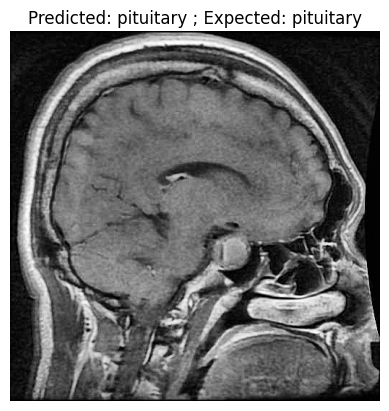

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


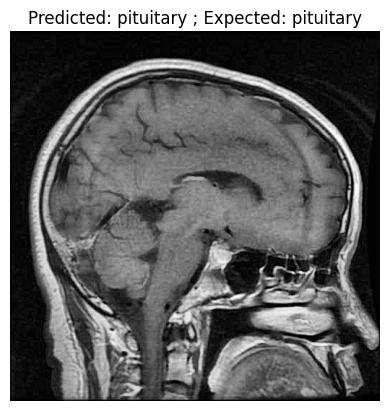

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


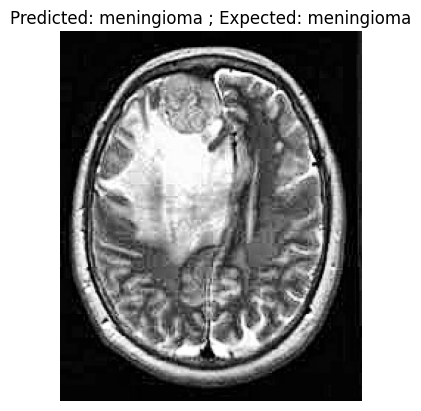

In [32]:
visualize_results(3,source='test')

# final -> unet + cnn

# DOWNLOAD MODELS FROM COLAB

In [66]:
from google.colab import files

files.download("/content/unet_best.keras")
files.download("/content/cnn_best.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [87]:
def full_pipeline(img_path, true_label=None):

    # =========================
    # STEP 1: PREPROCESS for U-NET (256, grayscale)
    # =========================
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (SEG_IMG_SIZE, SEG_IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=-1)   # (256,256,1)

    # =========================
    # STEP 2: U-NET MASK
    # =========================
    pred = unet_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
    mask = (pred > 0.5).astype(np.uint8)

    # =========================
    # STEP 3: APPLY MASK
    # =========================
    masked_img = img * mask

    # =========================
    # STEP 4: PREPARE FOR CNN (USE ORIGINAL IMAGE)
    # =========================
    cnn_input = cv2.resize(img, (RED_IMG_SIZE, RED_IMG_SIZE))
    cnn_input = np.expand_dims(cnn_input, axis=0)

    # =========================
    # STEP 5: CNN PREDICTION
    # =========================
    pred = cnn_model.predict(cnn_input, verbose=0)[0]
    class_idx = np.argmax(pred)
    confidence = pred[class_idx]

    pred_class = classes[class_idx]

    # =========================
    # PRINT OUTPUT
    # =========================
    print("\nImage:", img_path)
    if true_label:
        print("Actual:", true_label)

    print(f"Prediction: {pred_class} ({confidence:.2f})")

    if true_label:
        print("Correct ✅" if pred_class == true_label else "Wrong ❌")

    # =========================
    # SHOW IMAGES
    # =========================
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title("Input")

    plt.subplot(1,3,2)
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.title("Mask")

    plt.subplot(1,3,3)
    plt.imshow(masked_img.squeeze(), cmap='gray')
    plt.title(f"Pred: {pred_class}")

    plt.show()

In [88]:
def test_random_image():
    all_data = []

    for label in classes:
        folder = os.path.join(test_dir, label)
        for file in os.listdir(folder):
            all_data.append((os.path.join(folder, file), label))

    img_path, label = random.choice(all_data)

    full_pipeline(img_path, true_label=label)


Image: /content/archive (5)/DATASET/classification/Testing/glioma/enh_Te-gl_0184.jpg
Actual: glioma
Prediction: glioma (1.00)
Correct ✅


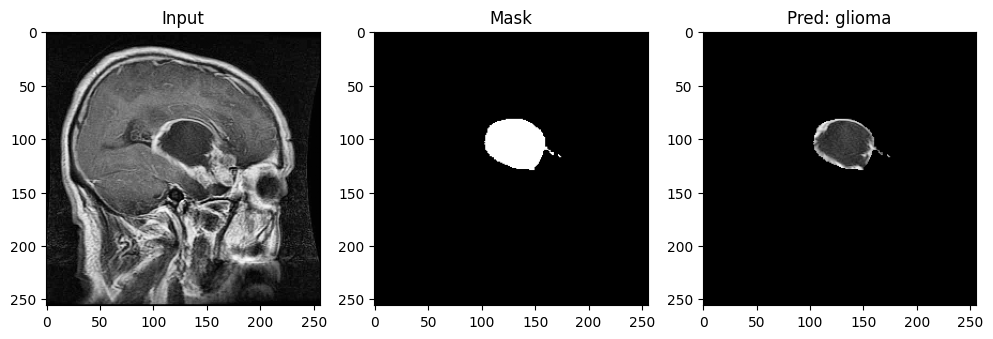

In [92]:
test_random_image()

In [93]:
def evaluate_pipeline():

    correct = 0
    total = 0

    for label in classes:
        folder = os.path.join(test_dir, label)

        for file in os.listdir(folder):
            img_path = os.path.join(folder, file)

            # =========================
            # PREPROCESS (same as pipeline)
            # =========================
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (SEG_IMG_SIZE, SEG_IMG_SIZE))
            img = img / 255.0
            img = np.expand_dims(img, axis=-1)

            # =========================
            # U-NET (mask)
            # =========================
            pred_mask = unet_model.predict(np.expand_dims(img, axis=0), verbose=0)[0]
            mask = (pred_mask > 0.5).astype(np.uint8)

            # =========================
            # APPLY MASK (optional, only for visualization)
            # =========================
            masked_img = img * mask

            # =========================
            # CNN INPUT (IMPORTANT: original image)
            # =========================
            cnn_input = cv2.resize(img, (RED_IMG_SIZE, RED_IMG_SIZE))
            cnn_input = np.expand_dims(cnn_input, axis=0)

            # =========================
            # PREDICTION
            # =========================
            pred = cnn_model.predict(cnn_input, verbose=0)[0]
            pred_class = classes[np.argmax(pred)]

            # =========================
            # ACCURACY COUNT
            # =========================
            if pred_class == label:
                correct += 1

            total += 1

    accuracy = correct / total

    print(f"\nPipeline Accuracy: {accuracy:.4f}")

In [94]:
evaluate_pipeline()


Pipeline Accuracy: 0.8940
